## Evaluate Ranking

In [1]:
import pandas as pd
import json
class CEA_Evaluator:
    def __init__(self, answer_file_path, round=1):
        self.answer_file_path = answer_file_path
        self.round = round

    def _evaluate(self, client_payload, _context={}):

        submission_file_path = client_payload["submission_file_path"]
        gt_cell_ent = dict()
        gt = pd.read_csv(self.answer_file_path, delimiter=',', names=['tab_id', 'row_id', 'col_id', 'entity'],dtype={'tab_id': str, 'row_id': str, 'col_id': str, 'entity': str}, keep_default_na=False)
        for _, row in gt.iterrows():
            cell = '%s %s %s' % (row['tab_id'], row['row_id'], row['col_id'])
            gt_cell_ent[cell] = row['entity']

        correct_cells, annotated_cells = set(), set()
        sub = pd.read_csv(submission_file_path, delimiter=',', names=['tab_id', 'row_id', 'col_id', 'entity'],dtype={'tab_id': str, 'row_id': str, 'col_id': str, 'entity': str}, keep_default_na=False)
        for _, row in sub.iterrows():
            cell = '%s %s %s' % (row['tab_id'], row['row_id'], row['col_id'])
            if cell in gt_cell_ent:
                if cell in annotated_cells:
                    print(cell)
                    raise Exception("Duplicate cells in the submission file")
                else:
                    annotated_cells.add(cell)

                annotation = row['entity']
                if not annotation.startswith('http://www.wikidata.org/entity/'):
                    annotation = 'http://www.wikidata.org/entity/' + annotation

                if annotation.lower() in gt_cell_ent[cell].lower().split():
                    correct_cells.add(cell)
                else:
                    #print('%s,%s' % (cell.replace(' ', ','), gt_cell_ent[cell]))
                    continue

        precision = len(correct_cells) / len(annotated_cells) if len(annotated_cells) > 0 else 0.0
        recall = len(correct_cells) / len(gt_cell_ent.keys())
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        main_score = f1
        secondary_score = precision
        print('F1: %.3f, Precision: %.3f, Recall: %.3f' % (f1, precision, recall))
        _result_object = {
            "score": main_score,
            "score_secondary": secondary_score
        }
        return _result_object

class CTA_Evaluator:
  def __init__(self, answer_file_path, gt_ancestor, gt_descendent, round=1):
    self.answer_file_path = answer_file_path
    self.gt_ancestor = gt_ancestor
    self.gt_descendent = gt_descendent
    self.round = round

  def _evaluate(self, client_payload, _context={}):
    submission_file_path = client_payload["submission_file_path"]

    cols, col_type = set(), dict()
    gt = pd.read_csv(self.answer_file_path, delimiter=',', names=['tab_id', 'col_id', 'type'],dtype={'tab_id': str, 'col_id': str, 'type': str}, keep_default_na=False)
    for _, row in gt.iterrows():
        col = '%s %s' % (row['tab_id'], row['col_id'])
        gt_type = row['type']
        col_type[col] = gt_type
        cols.add(col)

    annotated_cols = set()
    total_score = 0
    sub = pd.read_csv(submission_file_path, delimiter=',', names=['tab_id', 'col_id', 'annotation'],dtype={'tab_id': str, 'col_id': str, 'annotation': str}, keep_default_na=False)
    for _, row in sub.iterrows():
        col = '%s %s' % (row['tab_id'], row['col_id'])
        if col in annotated_cols:
            # continue
            print(col)
            raise Exception("Duplicate columns in the submission file")
        else:
            annotated_cols.add(col)
        annotation = row['annotation']
        if not annotation.startswith('http://www.wikidata.org/entity/'):
            annotation = 'http://www.wikidata.org/entity/' + annotation

        if col in cols:
            max_score = 0
            for gt_type in col_type[col].split():
                ancestor = self.gt_ancestor[gt_type]
                ancestor_keys = [k.lower() for k in ancestor]
                descendent = self.gt_descendent[gt_type]
                descendent_keys = [k.lower() for k in descendent]
                if annotation.lower() == gt_type.lower():
                    score = 1.0
                elif annotation.lower() in ancestor_keys:
                    depth = int(ancestor[annotation])
                    if depth <= 5:
                        score = pow(0.8, depth)
                    else:
                        score = 0
                elif annotation.lower() in descendent_keys:
                    depth = int(descendent[annotation])
                    if depth <= 3:
                        score = pow(0.7, depth)
                    else:
                        score = 0
                else:
                    score = 0
                if score > max_score:
                    max_score = score
            if max_score < 0.7:
                s_tmp = col.replace(' ', ',')
                #print('%s,%s' % (s_tmp, col_type[col]))
            total_score += max_score

    precision = total_score / len(annotated_cols) if len(annotated_cols) > 0 else 0
    recall = total_score / len(cols)
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    main_score = f1
    secondary_score = precision

    print('F1: %.3f, Precision: %.3f, Recall: %.3f' % (f1, precision, recall))

    _result_object = {
        "score": main_score,
        "score_secondary": secondary_score
    }
    return _result_object
  
class CPA_Evaluator:
  def __init__(self, answer_file_path, round=1):
    self.answer_file_path = answer_file_path
    self.round = round

  def _evaluate(self, client_payload, _context={}):
    submission_file_path = client_payload["submission_file_path"]

    gt_cols_pro = dict()
    gt = pd.read_csv(self.answer_file_path, delimiter=',', names=['tab_id', 'sub_col_id', 'obj_col_id', 'property'],dtype={'tab_id': str, 'sub_col_id': str, 'obj_col_id': str, 'property': str}, keep_default_na=False)
    for _, row in gt.iterrows():
        cols = '%s %s %s' % (row['tab_id'], row['sub_col_id'], row['obj_col_id'])
        gt_cols_pro[cols] = row['property']

    annotated_cols, correct_cols = set(), set()
    sub = pd.read_csv(submission_file_path, delimiter=',', names=['tab_id', 'sub_col_id', 'obj_col_id', 'property'],dtype={'tab_id': str, 'sub_col_id': str, 'obj_col_id': str, 'property': str}, keep_default_na=False)
    for _, row in sub.iterrows():
        cols = '%s %s %s' % (row['tab_id'], row['sub_col_id'], row['obj_col_id'])
        if cols in gt_cols_pro:
            if cols in annotated_cols:
                # continue
                #print(cols)
                raise Exception("Duplicate column pairs in the submission file")
            else:
                annotated_cols.add(cols)
            annotation = row['property']
            if not annotation.startswith('http://www.wikidata.org/prop/direct/'):
                annotation = 'http://www.wikidata.org/prop/direct/' + annotation
            if annotation.lower() == gt_cols_pro[cols].lower():
                correct_cols.add(cols)
            else:
                #print('%s,%s' % (cols.replace(' ', ','), gt_cols_pro[cols]))
                continue

    precision = float(len(correct_cols)) / len(annotated_cols) if len(annotated_cols) > 0 else 0.0
    recall = float(len(correct_cols)) / len(gt_cols_pro.keys())
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    main_score = f1
    secondary_score = precision
    print('F1: %.3f, Precision: %.3f, Recall: %.3f' % (f1, precision, recall))

    _result_object = {"score": main_score,"score_secondary": secondary_score}
    return _result_object
  
def evaluate_all(ground_truth_file_cea, submission_file_cea, ground_truth_file_cta, submission_file_cta, ground_truth_file_cpa, submission_file_cpa, gt_ancestor, gt_descendent, model ):
    print("Evaluating model : ", model)
    cea_evaluator = CEA_Evaluator(ground_truth_file_cea,1)
    cea_evaluator._evaluate({"submission_file_path": submission_file_cea})
    cta_evaluator = CTA_Evaluator(ground_truth_file_cta, gt_ancestor, gt_descendent, 1)
    cta_evaluator._evaluate({"submission_file_path": submission_file_cta})
    cpa_evaluator = CPA_Evaluator(ground_truth_file_cpa, 1)
    cpa_evaluator._evaluate({"submission_file_path": submission_file_cpa})
def load_hierarchy(ancestor_path, descendent_path):
    return json.load(open(ancestor_path)), json.load(open(descendent_path))


## TEST

In [2]:
ground_truth_file = "Testing_data/cea_gt.csv"

CEA_evaluator = CEA_Evaluator(ground_truth_file, round=1)
cta_ancestor, cta_descendent = load_hierarchy("Testing_data/cta_gt_ancestor.json","Testing_data/cta_gt_descendent.json")

CTA_evaluator = CTA_Evaluator("Testing_data/cta_gt.csv", gt_ancestor=cta_ancestor, gt_descendent=cta_descendent, round=1)
CPA_evaluator = CPA_Evaluator("Testing_data/cpa_gt.csv", round=1)

limited_slm_method = "Testing_data/Ranking/methods/limited_slm/cea.csv"
slm_method = "Testing_data/Ranking/methods/full_slm/cea.csv"
slm_context_method = "Testing_data/Ranking/methods/slm_context/cea.csv"
no_slm_method = "Testing_data/Ranking/methods/no_slm/cea.csv"

limited_slm_method_cta = "Testing_data/Ranking/methods/limited_slm/cta.csv"
slm_method_cta = "Testing_data/Ranking/methods/full_slm/cta.csv"
slm_context_method_cta = "Testing_data/Ranking/methods/slm_context/cta.csv"
no_slm_method_cta = "Testing_data/Ranking/methods/no_slm/cta.csv"

limited_slm_method_cpa = "Testing_data/Ranking/methods/limited_slm/cpa.csv"
slm_method_cpa = "Testing_data/Ranking/methods/full_slm/cpa.csv"
slm_context_method_cpa = "Testing_data/Ranking/methods/slm_context/cpa.csv"
no_slm_method_cpa = "Testing_data/Ranking/methods/no_slm/cpa.csv"


evaluate_all(ground_truth_file, limited_slm_method, "Testing_data/cta_gt.csv", limited_slm_method_cta, "Testing_data/cpa_gt.csv", limited_slm_method_cpa, cta_ancestor, cta_descendent, "Limited SLM ")
evaluate_all(ground_truth_file, slm_method, "Testing_data/cta_gt.csv", slm_method_cta, "Testing_data/cpa_gt.csv", slm_method_cpa, cta_ancestor, cta_descendent, "Full SLM ")
evaluate_all(ground_truth_file, slm_context_method, "Testing_data/cta_gt.csv", slm_context_method_cta, "Testing_data/cpa_gt.csv", slm_context_method_cpa, cta_ancestor, cta_descendent, "SLM with Context ")
evaluate_all(ground_truth_file, no_slm_method, "Testing_data/cta_gt.csv", no_slm_method_cta, "Testing_data/cpa_gt.csv", no_slm_method_cpa, cta_ancestor, cta_descendent, "No SLM ")


Evaluating model :  Limited SLM 
F1: 0.731, Precision: 0.740, Recall: 0.723
F1: 0.751, Precision: 0.751, Recall: 0.750
F1: 0.914, Precision: 0.990, Recall: 0.849
Evaluating model :  Full SLM 
F1: 0.728, Precision: 0.737, Recall: 0.720
F1: 0.699, Precision: 0.699, Recall: 0.698
F1: 0.906, Precision: 0.983, Recall: 0.839
Evaluating model :  SLM with Context 
F1: 0.717, Precision: 0.726, Recall: 0.709
F1: 0.740, Precision: 0.741, Recall: 0.740
F1: 0.903, Precision: 0.985, Recall: 0.834
Evaluating model :  No SLM 
F1: 0.730, Precision: 0.739, Recall: 0.721
F1: 0.729, Precision: 0.729, Recall: 0.728
F1: 0.903, Precision: 0.982, Recall: 0.837


In [4]:
ENT_PREFIX = 'http://www.wikidata.org/entity/'
PROP_PREFIX = 'http://www.wikidata.org/prop/direct/'

def _norm(annotation, prefix):
    annotation = annotation.strip()
    return annotation if annotation.startswith(prefix) else prefix + annotation

def _load_annotations(path, key_cols, prefix):
    df = pd.read_csv(path, delimiter=',', names=key_cols + ['ann'], dtype=str, keep_default_na=False)
    return {tuple(row[c] for c in key_cols): _norm(row['ann'], prefix) for _, row in df.iterrows()}

def _cea_score(ann, gt):
    return 1.0 if ann.lower() in gt.lower().split() else 0.0

def _cpa_score(ann, gt):
    return 1.0 if ann.lower() == gt.lower() else 0.0

def _cta_score(ann, gt_types):
    max_score = 0.0
    for gt_type in gt_types.split():
        ancestor = {k.lower(): v for k, v in cta_ancestor[gt_type].items()}
        descendent = {k.lower(): v for k, v in cta_descendent[gt_type].items()}
        if ann.lower() == gt_type.lower():
            score = 1.0
        elif ann.lower() in ancestor:
            depth = int(ancestor[ann.lower()])
            score = pow(0.8, depth) if depth <= 5 else 0.0
        elif ann.lower() in descendent:
            depth = int(descendent[ann.lower()])
            score = pow(0.7, depth) if depth <= 3 else 0.0
        else:
            score = 0.0
        max_score = max(max_score, score)
    return max_score

TASKS = {
    'CEA': dict(keys=['tab_id', 'row_id', 'col_id'], prefix=ENT_PREFIX,gt="Testing_data/cea_gt.csv", score=_cea_score),
    'CTA': dict(keys=['tab_id', 'col_id'], prefix=ENT_PREFIX,gt="Testing_data/cta_gt.csv", score=_cta_score),
    'CPA': dict(keys=['tab_id', 'sub_col_id', 'obj_col_id'], prefix=PROP_PREFIX,gt="Testing_data/cpa_gt.csv", score=_cpa_score)
}

def compare_to_baseline(task, baseline_path, other_paths, baseline_name="No SLM"):
    cfg = TASKS[task]
    gt = _load_annotations(cfg['gt'], cfg['keys'], '')
    base = _load_annotations(baseline_path, cfg['keys'], cfg['prefix'])
    rows = []
    for name, path in other_paths.items():
        other = _load_annotations(path, cfg['keys'], cfg['prefix'])
        common = set(base) & set(other) & set(gt)
        changed = fixed = broken = lateral = equivalent = 0
        for k in common:
            if base[k] == other[k]:
                continue
            changed += 1
            s_base, s_other = cfg['score'](base[k], gt[k]), cfg['score'](other[k], gt[k])
            if s_other > s_base:
                fixed += 1
            elif s_other < s_base:
                broken += 1
            elif s_base == 0:
                lateral += 1
            else:
                continue
        rows.append({
            'method': name,
            'annotations': len(common),
            'changed': changed,
            'changed_%': round(100 * changed / len(common), 2) if common else 0.0,
            'fixed': fixed,
            'broken': broken,
            'wrong->wrong': lateral,
            'net': fixed - broken})
    df = pd.DataFrame(rows).set_index('method')
    print("%s : changes vs %s" % (task, baseline_name))
    print(df.to_string())
    print()
    return df

methods_dir = "Testing_data/Ranking/methods"
other_methods = {
    'Limited SLM': "%s/limited_slm" % methods_dir,
    'Full SLM': "%s/full_slm" % methods_dir,
    'SLM with Context': "%s/slm_context" % methods_dir,
    'Finetuned LoRA 3B Context': "Testing_data/Ranking/finetuning/lora_3b",
    'Finetuned LoRA 7B Context': "Testing_data/Ranking/finetuning/lora_7b"}

diffs = {}
for task, fname in [('CEA', 'cea.csv'), ('CTA', 'cta.csv'), ('CPA', 'cpa.csv')]:
    diffs[task] = compare_to_baseline(task,"%s/no_slm/%s" % (methods_dir, fname),{n: "%s/%s" % (p, fname) for n, p in other_methods.items()})


CEA : changes vs No SLM
                           annotations  changed  changed_%  fixed  broken  wrong->wrong  net
method                                                                                      
Limited SLM                       4147      598      14.42    182     175           241    7
Full SLM                          4147       56       1.35     16      22            18   -6
SLM with Context                  4147      879      21.20    219     271           389  -52
Finetuned LoRA 3B Context         4147      774      18.66    340     136           298  204
Finetuned LoRA 7B Context         4147      720      17.36    477      30           213  447

CTA : changes vs No SLM
                           annotations  changed  changed_%  fixed  broken  wrong->wrong  net
method                                                                                      
Limited SLM                        622      166      26.69     68      59            39    9
Full SLM             

In [5]:
def _cta_detail(ann, gt_types):
    best = (0.0, 'miss', None)
    for gt_type in gt_types.split():
        ancestor = {k.lower(): v for k, v in cta_ancestor[gt_type].items()}
        descendent = {k.lower(): v for k, v in cta_descendent[gt_type].items()}
        a = ann.lower()
        if a == gt_type.lower():
            cand = (1.0, 'exact', 0)
        elif a in ancestor:
            d = int(ancestor[a])
            cand = (pow(0.8, d), 'ancestor', d) if d <= 5 else (0.0, 'ancestor_far', d)
        elif a in descendent:
            d = int(descendent[a])
            cand = (pow(0.7, d), 'descendant', d) if d <= 3 else (0.0, 'descendant_far', d)
        else:
            cand = (0.0, 'miss', None)
        if cand[0] > best[0] or best[1] == 'miss':
            best = cand
    return best


def cta_breakdown(paths, gt_path="Testing_data/cta_gt.csv"):
    keys = TASKS['CTA']['keys']
    gt = _load_annotations(gt_path, keys, '')
    rows, depth_rows = [], []
    for name, path in paths.items():
        ann = _load_annotations(path, keys, ENT_PREFIX)
        common = sorted(set(ann) & set(gt))
        kinds, depths, total = {}, {}, 0.0
        for k in common:
            score, kind, depth = _cta_detail(ann[k], gt[k])
            kinds[kind] = kinds.get(kind, 0) + 1
            total += score
            if kind in ('ancestor', 'descendant'):
                depths[(kind, depth)] = depths.get((kind, depth), 0) + 1
        n = len(common)
        rows.append({
            'method': name, 'annotations': n,
            'exact': kinds.get('exact', 0),
            'ancestor': kinds.get('ancestor', 0),
            'descendant': kinds.get('descendant', 0),
            'far': kinds.get('ancestor_far', 0) + kinds.get('descendant_far', 0),
            'miss': kinds.get('miss', 0),
            'exact_%': round(100 * kinds.get('exact', 0) / n, 2) if n else 0.0,
            'partial_%': round(100 * (kinds.get('ancestor', 0) + kinds.get('descendant', 0)) / n, 2) if n else 0.0,
            'mean_cscore': round(total / n, 4) if n else 0.0})
        for (kind, d), c in sorted(depths.items()):
            depth_rows.append({'method': name, 'kind': kind, 'depth': d, 'count': c})

    df = pd.DataFrame(rows).set_index('method')
    print("CTA : type-hierarchy breakdown")
    print(df.to_string())
    print()
    dd = pd.DataFrame(depth_rows)
    if not dd.empty:
        print("CTA : depth distribution of partial matches")
        print(dd.pivot_table(index='method', columns=['kind', 'depth'],values='count', fill_value=0).to_string())
    return df, dd


all_cta = {'No SLM': "%s/no_slm" % methods_dir}
all_cta.update(other_methods)
cta_df, cta_depths = cta_breakdown({n: "%s/cta.csv" % p for n, p in all_cta.items()})

CTA : type-hierarchy breakdown
                           annotations  exact  ancestor  descendant  far  miss  exact_%  partial_%  mean_cscore
method                                                                                                         
No SLM                             622    431        31           4    1   155    69.29       5.63       0.7292
Limited SLM                        622    435        40           7    2   138    69.94       7.56       0.7514
Full SLM                           622    389        56          10    2   165    62.54      10.61       0.6993
SLM with Context                   622    429        39           7    1   146    68.97       7.40       0.7410
Finetuned LoRA 3B Context          622    469        40           6    0   107    75.40       7.40       0.8031
Finetuned LoRA 7B Context          622    474        43           4    2    99    76.21       7.56       0.8149

CTA : depth distribution of partial matches
kind                      an

In [6]:
test_cea = "Testing_data/Ranking/finetuning/lora_3b/cea.csv"
test_cta = "Testing_data/Ranking/finetuning/lora_3b/cta.csv"
test_cpa = "Testing_data/Ranking/finetuning/lora_3b/cpa.csv"

test_cea2 = "Testing_data/Ranking/finetuning/lora_7b/cea.csv"
test_cta2 = "Testing_data/Ranking/finetuning/lora_7b/cta.csv"
test_cpa2 = "Testing_data/Ranking/finetuning/lora_7b/cpa.csv"

evaluate_all(ground_truth_file, test_cea, "Testing_data/cta_gt.csv", test_cta, "Testing_data/cpa_gt.csv", test_cpa, cta_ancestor, cta_descendent, "Finetuning with Lora3b SLM Context")
evaluate_all(ground_truth_file, test_cea2, "Testing_data/cta_gt.csv", test_cta2, "Testing_data/cpa_gt.csv", test_cpa2, cta_ancestor, cta_descendent, "Finetuning with Lora7b SLM Context ")

Evaluating model :  Finetuning with Lora3b SLM Context
F1: 0.778, Precision: 0.788, Recall: 0.769
F1: 0.802, Precision: 0.803, Recall: 0.802
F1: 0.938, Precision: 0.991, Recall: 0.892
Evaluating model :  Finetuning with Lora7b SLM Context 
F1: 0.836, Precision: 0.846, Recall: 0.826
F1: 0.814, Precision: 0.815, Recall: 0.814
F1: 0.939, Precision: 0.988, Recall: 0.894


In [ ]:
margin0_cea = "Testing_data/Ranking/context_margin/m000/cea.csv"
margin0_cta = "Testing_data/Ranking/context_margin/m000/cta.csv"
margin0_cpa = "Testing_data/Ranking/context_margin/m000/cpa.csv"

margin5_cea = "Testing_data/Ranking/context_margin/m005/cea.csv"
margin5_cta = "Testing_data/Ranking/context_margin/m005/cta.csv"
margin5_cpa = "Testing_data/Ranking/context_margin/m005/cpa.csv"


margin20_cea = "Testing_data/Ranking/context_margin/m020/cea.csv"
margin20_cta = "Testing_data/Ranking/context_margin/m020/cta.csv"
margin20_cpa = "Testing_data/Ranking/context_margin/m020/cpa.csv"

margin40_cea = "Testing_data/Ranking/context_margin/m040/cea.csv"
margin40_cta = "Testing_data/Ranking/context_margin/m040/cta.csv"
margin40_cpa = "Testing_data/Ranking/context_margin/m040/cpa.csv"

margin100_cea = "Testing_data/Ranking/context_margin/m100/cea.csv"
margin100_cta = "Testing_data/Ranking/context_margin/m100/cta.csv"
margin100_cpa = "Testing_data/Ranking/context_margin/m100/cpa.csv"

evaluate_all(ground_truth_file, margin0_cea, "Testing_data/cta_gt.csv", margin0_cta, "Testing_data/cpa_gt.csv", margin0_cpa, cta_ancestor, cta_descendent, "Margin 0 ")
evaluate_all(ground_truth_file, margin5_cea, "Testing_data/cta_gt.csv", margin5_cta, "Testing_data/cpa_gt.csv", margin5_cpa, cta_ancestor, cta_descendent, "Margin 5 ")
evaluate_all(ground_truth_file, margin20_cea, "Testing_data/cta_gt.csv", margin20_cta, "Testing_data/cpa_gt.csv", margin20_cpa, cta_ancestor, cta_descendent, "Margin 20 ")
evaluate_all(ground_truth_file, margin40_cea, "Testing_data/cta_gt.csv", margin40_cta, "Testing_data/cpa_gt.csv", margin40_cpa, cta_ancestor, cta_descendent, "Margin 40 ")
evaluate_all(ground_truth_file, margin100_cea, "Testing_data/cta_gt.csv", margin100_cta, "Testing_data/cpa_gt.csv", margin100_cpa, cta_ancestor, cta_descendent, "Margin 100 ")

Evaluating model :  Margin 0 
F1: 0.730, Precision: 0.739, Recall: 0.721
F1: 0.764, Precision: 0.764, Recall: 0.763
F1: 0.908, Precision: 0.987, Recall: 0.841
Evaluating model :  Margin 5 
F1: 0.721, Precision: 0.730, Recall: 0.713
F1: 0.748, Precision: 0.749, Recall: 0.747
F1: 0.905, Precision: 0.990, Recall: 0.834
Evaluating model :  Margin 20 
F1: 0.708, Precision: 0.717, Recall: 0.700
F1: 0.743, Precision: 0.744, Recall: 0.742
F1: 0.899, Precision: 0.983, Recall: 0.828
Evaluating model :  Margin 40 
F1: 0.697, Precision: 0.706, Recall: 0.689
F1: 0.736, Precision: 0.737, Recall: 0.735
F1: 0.899, Precision: 0.980, Recall: 0.830
Evaluating model :  Margin 100 
F1: 0.694, Precision: 0.703, Recall: 0.686
F1: 0.726, Precision: 0.727, Recall: 0.725
F1: 0.900, Precision: 0.980, Recall: 0.832


## Full methods

In [7]:
import json

gemma2_9b_cea = "Testing_data/Ranking/models/gemma2_9b/cea.csv"
gemma2_9b_cta = "Testing_data/Ranking/models/gemma2_9b/cta.csv"
gemma2_9b_cpa = "Testing_data/Ranking/models/gemma2_9b/cpa.csv"

gemma3_1b_cea = "Testing_data/Ranking/models/gemma3_1b/cea.csv"
gemma3_1b_cta = "Testing_data/Ranking/models/gemma3_1b/cta.csv"
gemma3_1b_cpa = "Testing_data/Ranking/models/gemma3_1b/cpa.csv"

glm4_9b_cea = "Testing_data/Ranking/models/glm4_9b/cea.csv"
glm4_9b_cta = "Testing_data/Ranking/models/glm4_9b/cta.csv"
glm4_9b_cpa = "Testing_data/Ranking/models/glm4_9b/cpa.csv"

qwen25_0_5b_cea = "Testing_data/Ranking/models/qwen25_0_5b/cea.csv"
qwen25_0_5b_cta = "Testing_data/Ranking/models/qwen25_0_5b/cta.csv"
qwen25_0_5b_cpa = "Testing_data/Ranking/models/qwen25_0_5b/cpa.csv"

qwen25_1_5b_cea = "Testing_data/Ranking/models/qwen25_1_5b/cea.csv"
qwen25_1_5b_cta = "Testing_data/Ranking/models/qwen25_1_5b/cta.csv"
qwen25_1_5b_cpa = "Testing_data/Ranking/models/qwen25_1_5b/cpa.csv"

qwen25_7b_cea = "Testing_data/Ranking/models/qwen25_7b/cea.csv"
qwen25_7b_cta = "Testing_data/Ranking/models/qwen25_7b/cta.csv"
qwen25_7b_cpa = "Testing_data/Ranking/models/qwen25_7b/cpa.csv"

llama31_8b_cea = "Testing_data/Ranking/models/llama31_8b/cea.csv"
llama31_8b_cta = "Testing_data/Ranking/models/llama31_8b/cta.csv"
llama31_8b_cpa = "Testing_data/Ranking/models/llama31_8b/cpa.csv"

llama32_1b_cea = "Testing_data/Ranking/models/llama32_1b/cea.csv"
llama32_1b_cta = "Testing_data/Ranking/models/llama32_1b/cta.csv"
llama32_1b_cpa = "Testing_data/Ranking/models/llama32_1b/cpa.csv"

llama32_3b_cea = "Testing_data/Ranking/models/llama32_3b/cea.csv"
llama32_3b_cta = "Testing_data/Ranking/models/llama32_3b/cta.csv"
llama32_3b_cpa = "Testing_data/Ranking/models/llama32_3b/cpa.csv"

with open("Testing_data/cta_gt_ancestor.json") as f:
    cta_ancestor = json.load(f)
with open("Testing_data/cta_gt_descendent.json") as f:
    cta_descendent = json.load(f)

CTA_evaluator = CTA_Evaluator("Testing_data/cta_gt.csv", cta_ancestor, cta_descendent, round=1)
CPA_evaluator = CPA_Evaluator("Testing_data/cpa_gt.csv", round=1)

evaluate_all(ground_truth_file, gemma2_9b_cea, "Testing_data/cta_gt.csv", gemma2_9b_cta, "Testing_data/cpa_gt.csv", gemma2_9b_cpa, cta_ancestor, cta_descendent, "Gemma2_9b")
evaluate_all(ground_truth_file, gemma3_1b_cea, "Testing_data/cta_gt.csv", gemma3_1b_cta, "Testing_data/cpa_gt.csv", gemma3_1b_cpa, cta_ancestor, cta_descendent, "Gemma3_1b")
evaluate_all(ground_truth_file, glm4_9b_cea,"Testing_data/cta_gt.csv", glm4_9b_cta, "Testing_data/cpa_gt.csv", glm4_9b_cpa, cta_ancestor, cta_descendent, "GLM4_9b")
evaluate_all(ground_truth_file, qwen25_0_5b_cea, "Testing_data/cta_gt.csv", qwen25_0_5b_cta, "Testing_data/cpa_gt.csv", qwen25_0_5b_cpa, cta_ancestor, cta_descendent, "Qwen25_0.5b")
evaluate_all(ground_truth_file, qwen25_1_5b_cea, "Testing_data/cta_gt.csv", qwen25_1_5b_cta, "Testing_data/cpa_gt.csv", qwen25_1_5b_cpa, cta_ancestor, cta_descendent, "Qwen25_1.5b")
evaluate_all(ground_truth_file, qwen25_7b_cea, "Testing_data/cta_gt.csv", qwen25_7b_cta, "Testing_data/cpa_gt.csv", qwen25_7b_cpa, cta_ancestor, cta_descendent, "Qwen25_7b")
evaluate_all(ground_truth_file, llama31_8b_cea, "Testing_data/cta_gt.csv", llama31_8b_cta, "Testing_data/cpa_gt.csv", llama31_8b_cpa, cta_ancestor, cta_descendent, "Llama31_8b")
evaluate_all(ground_truth_file, llama32_1b_cea, "Testing_data/cta_gt.csv", llama32_1b_cta, "Testing_data/cpa_gt.csv", llama32_1b_cpa, cta_ancestor, cta_descendent, "Llama32_1b")
evaluate_all(ground_truth_file, llama32_3b_cea, "Testing_data/cta_gt.csv", llama32_3b_cta, "Testing_data/cpa_gt.csv", llama32_3b_cpa, cta_ancestor, cta_descendent, "Llama32_3b")



Evaluating model :  Gemma2_9b
F1: 0.747, Precision: 0.756, Recall: 0.738
F1: 0.759, Precision: 0.759, Recall: 0.758
F1: 0.907, Precision: 0.984, Recall: 0.842
Evaluating model :  Gemma3_1b
F1: 0.569, Precision: 0.576, Recall: 0.563
F1: 0.647, Precision: 0.648, Recall: 0.647
F1: 0.834, Precision: 0.970, Recall: 0.731
Evaluating model :  GLM4_9b
F1: 0.736, Precision: 0.745, Recall: 0.727
F1: 0.781, Precision: 0.782, Recall: 0.780
F1: 0.913, Precision: 0.984, Recall: 0.852
Evaluating model :  Qwen25_0.5b
F1: 0.686, Precision: 0.694, Recall: 0.678
F1: 0.756, Precision: 0.757, Recall: 0.756
F1: 0.892, Precision: 0.978, Recall: 0.820
Evaluating model :  Qwen25_1.5b
F1: 0.605, Precision: 0.613, Recall: 0.598
F1: 0.718, Precision: 0.719, Recall: 0.718
F1: 0.856, Precision: 0.977, Recall: 0.762
Evaluating model :  Qwen25_7b
F1: 0.717, Precision: 0.726, Recall: 0.709
F1: 0.763, Precision: 0.763, Recall: 0.762
F1: 0.899, Precision: 0.987, Recall: 0.825
Evaluating model :  Llama31_8b
F1: 0.752, Pr

## Table Llama

In [8]:
basic_cea = "Testing_data/Ranking/tablellama/default_prompts/cea.csv"
basic_cta = "Testing_data/Ranking/tablellama/default_prompts/cta.csv"
basic_cpa = "Testing_data/Ranking/tablellama/default_prompts/cpa.csv"

tablellama_cea = "Testing_data/Ranking/tablellama/tablellama_prompts/cea.csv"
tablellama_cta = "Testing_data/Ranking/tablellama/tablellama_prompts/cta.csv"
tablellama_cpa = "Testing_data/Ranking/tablellama/tablellama_prompts/cpa.csv"

evaluate_all(ground_truth_file, basic_cea, "Testing_data/cta_gt.csv", basic_cta, "Testing_data/cpa_gt.csv", basic_cpa, cta_ancestor, cta_descendent, "Basic TableLLaMA")
evaluate_all(ground_truth_file, tablellama_cea, "Testing_data/cta_gt.csv", tablellama_cta, "Testing_data/cpa_gt.csv", tablellama_cpa, cta_ancestor, cta_descendent, "TableLLaMA Prompts")

Evaluating model :  Basic TableLLaMA
F1: 0.648, Precision: 0.656, Recall: 0.641
F1: 0.759, Precision: 0.760, Recall: 0.759
F1: 0.867, Precision: 0.972, Recall: 0.783
Evaluating model :  TableLLaMA Prompts
F1: 0.682, Precision: 0.690, Recall: 0.674
F1: 0.711, Precision: 0.712, Recall: 0.711
F1: 0.881, Precision: 0.974, Recall: 0.804


## Prompt

In [9]:
one_shot_cea = "Testing_data/Ranking/prompts/oneshot/cea.csv"
one_shot_cta = "Testing_data/Ranking/prompts/oneshot/cta.csv"
one_shot_cpa = "Testing_data/Ranking/prompts/oneshot/cpa.csv"

few_shot_cea = "Testing_data/Ranking/prompts/fewshot/cea.csv"
few_shot_cta = "Testing_data/Ranking/prompts/fewshot/cta.csv"
few_shot_cpa = "Testing_data/Ranking/prompts/fewshot/cpa.csv"

cot_cea = "Testing_data/Ranking/prompts/cot/cea.csv"
cot_cta = "Testing_data/Ranking/prompts/cot/cta.csv"
cot_cpa = "Testing_data/Ranking/prompts/cot/cpa.csv"

sc_cea = "Testing_data/Ranking/prompts/sc/cea.csv"
sc_cta = "Testing_data/Ranking/prompts/sc/cta.csv"
sc_cpa = "Testing_data/Ranking/prompts/sc/cpa.csv"

evaluate_all(ground_truth_file, one_shot_cea, "Testing_data/cta_gt.csv", one_shot_cta, "Testing_data/cpa_gt.csv", one_shot_cpa, cta_ancestor, cta_descendent, "One-Shot Prompts")
evaluate_all(ground_truth_file, few_shot_cea, "Testing_data/cta_gt.csv", few_shot_cta, "Testing_data/cpa_gt.csv", few_shot_cpa, cta_ancestor, cta_descendent, "Few-Shot Prompts")
evaluate_all(ground_truth_file, cot_cea, "Testing_data/cta_gt.csv", cot_cta, "Testing_data/cpa_gt.csv", cot_cpa, cta_ancestor, cta_descendent, "Chain-of-Thought Prompts")
evaluate_all(ground_truth_file, sc_cea, "Testing_data/cta_gt.csv", sc_cta, "Testing_data/cpa_gt.csv", sc_cpa, cta_ancestor, cta_descendent, "Self-Consistency Prompts")


Evaluating model :  One-Shot Prompts
F1: 0.731, Precision: 0.739, Recall: 0.722
F1: 0.749, Precision: 0.750, Recall: 0.748
F1: 0.906, Precision: 0.985, Recall: 0.838
Evaluating model :  Few-Shot Prompts
F1: 0.731, Precision: 0.739, Recall: 0.722
F1: 0.751, Precision: 0.752, Recall: 0.750
F1: 0.908, Precision: 0.992, Recall: 0.837
Evaluating model :  Chain-of-Thought Prompts
F1: 0.683, Precision: 0.692, Recall: 0.675
F1: 0.727, Precision: 0.727, Recall: 0.726
F1: 0.881, Precision: 0.988, Recall: 0.796
Evaluating model :  Self-Consistency Prompts
F1: 0.723, Precision: 0.732, Recall: 0.714
F1: 0.750, Precision: 0.750, Recall: 0.749
F1: 0.902, Precision: 0.979, Recall: 0.837


## Without RAG

In [10]:
baseline_cea = "Testing_data/baseline/cea.csv"
baseline_cta = "Testing_data/baseline/cta.csv"
baseline_cpa = "Testing_data/baseline/cpa.csv"



evaluate_all(ground_truth_file, baseline_cea, "Testing_data/cta_gt.csv", baseline_cta, "Testing_data/cpa_gt.csv", baseline_cpa, cta_ancestor, cta_descendent, "Baseline")

Evaluating model :  Baseline
F1: 0.001, Precision: 0.002, Recall: 0.001
F1: 0.006, Precision: 0.025, Recall: 0.003
F1: 0.022, Precision: 0.083, Recall: 0.013


## INPUT

In [11]:
basic_prompt_10_cea = "Testing_data/Ranking/inputs/basic_prompt_10/cea.csv"
basic_prompt_10_cta = "Testing_data/Ranking/inputs/basic_prompt_10/cta.csv"
basic_prompt_10_cpa = "Testing_data/Ranking/inputs/basic_prompt_10/cpa.csv"

glm_9b_5_cea = "Testing_data/Ranking/inputs/glm_9b_5/cea.csv"
glm_9b_5_cta = "Testing_data/Ranking/inputs/glm_9b_5/cta.csv"
glm_9b_5_cpa = "Testing_data/Ranking/inputs/glm_9b_5/cpa.csv"

glm_9b_30_cea = "Testing_data/Ranking/inputs/glm_9b_30/cea.csv"
glm_9b_30_cta = "Testing_data/Ranking/inputs/glm_9b_30/cta.csv"
glm_9b_30_cpa = "Testing_data/Ranking/inputs/glm_9b_30/cpa.csv"

nollm_cea = "Testing_data/Ranking/inputs/nollm/cea.csv"
nollm_cta = "Testing_data/Ranking/inputs/nollm/cta.csv"
nollm_cpa = "Testing_data/Ranking/inputs/nollm/cpa.csv"

qwen25_0_5b_cea = "Testing_data/Ranking/inputs/qwen25_0_5b/cea.csv"
qwen25_0_5b_cta = "Testing_data/Ranking/inputs/qwen25_0_5b/cta.csv"
qwen25_0_5b_cpa = "Testing_data/Ranking/inputs/qwen25_0_5b/cpa.csv"

evaluate_all(ground_truth_file, basic_prompt_10_cea, "Testing_data/cta_gt.csv", basic_prompt_10_cta, "Testing_data/cpa_gt.csv", basic_prompt_10_cpa, cta_ancestor, cta_descendent, "Basic Prompt 10")
evaluate_all(ground_truth_file, glm_9b_5_cea, "Testing_data/cta_gt.csv", glm_9b_5_cta, "Testing_data/cpa_gt.csv", glm_9b_5_cpa, cta_ancestor, cta_descendent, "GLM 9B 5")
evaluate_all(ground_truth_file, glm_9b_30_cea, "Testing_data/cta_gt.csv", glm_9b_30_cta, "Testing_data/cpa_gt.csv", glm_9b_30_cpa, cta_ancestor, cta_descendent, "GLM 9B 30")
evaluate_all(ground_truth_file, nollm_cea, "Testing_data/cta_gt.csv", nollm_cta, "Testing_data/cpa_gt.csv", nollm_cpa, cta_ancestor, cta_descendent, "No LLM")
evaluate_all(ground_truth_file, qwen25_0_5b_cea, "Testing_data/cta_gt.csv", qwen25_0_5b_cta, "Testing_data/cpa_gt.csv", qwen25_0_5b_cpa, cta_ancestor, cta_descendent, "Qwen 25 0.5B")

Evaluating model :  Basic Prompt 10
F1: 0.562, Precision: 0.574, Recall: 0.550
F1: 0.626, Precision: 0.628, Recall: 0.624
F1: 0.834, Precision: 0.983, Recall: 0.724
Evaluating model :  GLM 9B 5
F1: 0.693, Precision: 0.701, Recall: 0.685
F1: 0.719, Precision: 0.720, Recall: 0.718
F1: 0.875, Precision: 0.977, Recall: 0.792
Evaluating model :  GLM 9B 30
F1: 0.704, Precision: 0.712, Recall: 0.695
F1: 0.748, Precision: 0.748, Recall: 0.747
F1: 0.904, Precision: 0.983, Recall: 0.837
Evaluating model :  No LLM
F1: 0.703, Precision: 0.709, Recall: 0.697
F1: 0.727, Precision: 0.727, Recall: 0.727
F1: 0.878, Precision: 0.978, Recall: 0.797
Evaluating model :  Qwen 25 0.5B
F1: 0.686, Precision: 0.692, Recall: 0.680
F1: 0.715, Precision: 0.716, Recall: 0.713
F1: 0.876, Precision: 0.981, Recall: 0.792


In [12]:
cea_limited = "Testing_data/Ranking/ranking_other_dataset/limited_slm/cea.csv"
cta_limited = "Testing_data/Ranking/ranking_other_dataset/limited_slm/cta.csv"
cpa_limited = "Testing_data/Ranking/ranking_other_dataset/limited_slm/cpa.csv"

cea_context = "Testing_data/Ranking/ranking_other_dataset/slm_context/cea.csv"
cta_context = "Testing_data/Ranking/ranking_other_dataset/slm_context/cta.csv"
cpa_context = "Testing_data/Ranking/ranking_other_dataset/slm_context/cpa.csv"

cea_finetuning = "Testing_data/Ranking/ranking_other_dataset/finetuning_context/cea.csv"
cta_finetuning = "Testing_data/Ranking/ranking_other_dataset/finetuning_context/cta.csv"
cpa_finetuning = "Testing_data/Ranking/ranking_other_dataset/finetuning_context/cpa.csv"

cea_finetuning_context_7b = "Testing_data/Ranking/ranking_other_dataset/finetuning_context_7b/cea.csv"
cta_finetuning_context_7b = "Testing_data/Ranking/ranking_other_dataset/finetuning_context_7b/cta.csv"
cpa_finetuning_context_7b = "Testing_data/Ranking/ranking_other_dataset/finetuning_context_7b/cpa.csv"

cea_no_slm = "Testing_data/Ranking/ranking_other_dataset/no_slm/cea.csv"
cta_no_slm = "Testing_data/Ranking/ranking_other_dataset/no_slm/cta.csv"
cpa_no_slm = "Testing_data/Ranking/ranking_other_dataset/no_slm/cpa.csv"

gt_cea = "Testing_data/Ranking/ranking_other_dataset/cea_gt.csv"
gt_cta = "Testing_data/Ranking/ranking_other_dataset/cta_gt.csv"
gt_cpa = "Testing_data/Ranking/ranking_other_dataset/cpa_gt.csv"
gt_ancestor, gt_descendent = load_hierarchy("Testing_data/Ranking/ranking_other_dataset/cta_gt_ancestor.json","Testing_data/Ranking/ranking_other_dataset/cta_gt_descendent.json")

evaluate_all(gt_cea, cea_no_slm, gt_cta, cta_no_slm, gt_cpa, cpa_no_slm, gt_ancestor, gt_descendent, "No SLM")
evaluate_all(gt_cea, cea_limited, gt_cta, cta_limited, gt_cpa, cpa_limited, gt_ancestor, gt_descendent, "Limited SLM")
evaluate_all(gt_cea, cea_context, gt_cta, cta_context, gt_cpa, cpa_context, gt_ancestor, gt_descendent, "SLM with Context")
evaluate_all(gt_cea, cea_finetuning, gt_cta, cta_finetuning, gt_cpa, cpa_finetuning, gt_ancestor, gt_descendent, "Finetuning with Context")
evaluate_all(gt_cea, cea_finetuning_context_7b, gt_cta, cta_finetuning_context_7b, gt_cpa, cpa_finetuning_context_7b, gt_ancestor, gt_descendent, "Finetuning with Context 7B")


Evaluating model :  No SLM
F1: 0.780, Precision: 0.844, Recall: 0.724
F1: 0.729, Precision: 0.743, Recall: 0.715
F1: 0.891, Precision: 0.985, Recall: 0.814
Evaluating model :  Limited SLM
F1: 0.795, Precision: 0.861, Recall: 0.739
F1: 0.835, Precision: 0.851, Recall: 0.819
F1: 0.905, Precision: 0.988, Recall: 0.834
Evaluating model :  SLM with Context
F1: 0.784, Precision: 0.849, Recall: 0.728
F1: 0.832, Precision: 0.848, Recall: 0.816
F1: 0.901, Precision: 0.988, Recall: 0.828
Evaluating model :  Finetuning with Context
F1: 0.807, Precision: 0.874, Recall: 0.750
F1: 0.855, Precision: 0.872, Recall: 0.839
F1: 0.908, Precision: 0.991, Recall: 0.838
Evaluating model :  Finetuning with Context 7B
F1: 0.814, Precision: 0.881, Recall: 0.756
F1: 0.847, Precision: 0.864, Recall: 0.832
F1: 0.912, Precision: 0.990, Recall: 0.846


In [13]:
other_dir = "Testing_data/Ranking/ranking_other_dataset"
other_ancestor, other_descendent = load_hierarchy("%s/cta_gt_ancestor.json" % other_dir, "%s/cta_gt_descendent.json" % other_dir)

def _cta_score_other(ann, gt_types):
    max_score = 0.0
    for gt_type in gt_types.split():
        ancestor = {k.lower(): v for k, v in other_ancestor[gt_type].items()}
        descendent = {k.lower(): v for k, v in other_descendent[gt_type].items()}
        if ann.lower() == gt_type.lower():
            score = 1.0
        elif ann.lower() in ancestor:
            depth = int(ancestor[ann.lower()])
            score = pow(0.8, depth) if depth <= 5 else 0.0
        elif ann.lower() in descendent:
            depth = int(descendent[ann.lower()])
            score = pow(0.7, depth) if depth <= 3 else 0.0
        else:
            score = 0.0
        max_score = max(max_score, score)
    return max_score

TASKS_OTHER = {
    'CEA': dict(keys=['tab_id', 'row_id', 'col_id'], prefix=ENT_PREFIX,gt="%s/cea_gt.csv" % other_dir, score=_cea_score),
    'CTA': dict(keys=['tab_id', 'col_id'], prefix=ENT_PREFIX,gt="%s/cta_gt.csv" % other_dir, score=_cta_score_other),
    'CPA': dict(keys=['tab_id', 'sub_col_id', 'obj_col_id'], prefix=PROP_PREFIX,gt="%s/cpa_gt.csv" % other_dir, score=_cpa_score)
}

def compare_to_baseline_tasks(task, baseline_path, other_paths, tasks, baseline_name="No SLM"):
    cfg = tasks[task]
    gt = _load_annotations(cfg['gt'], cfg['keys'], '')
    base = _load_annotations(baseline_path, cfg['keys'], cfg['prefix'])
    rows = []
    for name, path in other_paths.items():
        other = _load_annotations(path, cfg['keys'], cfg['prefix'])
        common = set(base) & set(other) & set(gt)
        changed = fixed = broken = lateral = 0
        for k in common:
            if base[k] == other[k]:
                continue
            changed += 1
            s_base, s_other = cfg['score'](base[k], gt[k]), cfg['score'](other[k], gt[k])
            if s_other > s_base:
                fixed += 1
            elif s_other < s_base:
                broken += 1
            elif s_base == 0:
                lateral += 1
            else:
                continue
        rows.append({
            'method': name,
            'annotations': len(common),
            'changed': changed,
            'changed_%': round(100 * changed / len(common), 2) if common else 0.0,
            'fixed': fixed,
            'broken': broken,
            'wrong->wrong': lateral,
            'net': fixed - broken})
    df = pd.DataFrame(rows).set_index('method')
    print("%s : changes vs %s" % (task, baseline_name))
    print(df.to_string())
    print()
    return df

other_dataset_methods = {
    'Limited SLM': "%s/limited_slm" % other_dir,
    'SLM with Context': "%s/slm_context" % other_dir,
    'Finetuning with Context': "%s/finetuning_context" % other_dir,
    'Finetuning with Context 7B': "%s/finetuning_context_7b" % other_dir}

diffs_other = {}
for task, fname in [('CEA', 'cea.csv'), ('CTA', 'cta.csv'), ('CPA', 'cpa.csv')]:
    diffs_other[task] = compare_to_baseline_tasks(task,"%s/no_slm/%s" % (other_dir, fname),{n: "%s/%s" % (p, fname) for n, p in other_dataset_methods.items()},TASKS_OTHER)


CEA : changes vs No SLM
                            annotations  changed  changed_%  fixed  broken  wrong->wrong  net
method                                                                                       
Limited SLM                       19257     1654       8.59    562     240           852  322
SLM with Context                  19257     1792       9.31    395     308          1089   87
Finetuning with Context           19257     1712       8.89    734     166           812  568
Finetuning with Context 7B        19257     1847       9.59    850     139           858  711

CTA : changes vs No SLM
                            annotations  changed  changed_%  fixed  broken  wrong->wrong  net
method                                                                                       
Limited SLM                         614      164      26.71    100      29            34   71
SLM with Context                    614      166      27.04     98      30            37   68
Finetuning 

## CTA Margin 

In [14]:
cea_k03 = "Testing_data/Ranking/cta_margin/k03/cea.csv"
cta_k03 = "Testing_data/Ranking/cta_margin/k03/cta.csv"
cpa_k03 = "Testing_data/Ranking/cta_margin/k03/cpa.csv"

cea_k10 = "Testing_data/Ranking/cta_margin/k10/cea.csv"
cta_k10 = "Testing_data/Ranking/cta_margin/k10/cta.csv"
cpa_k10 = "Testing_data/Ranking/cta_margin/k10/cpa.csv"

cea_k20 = "Testing_data/Ranking/cta_margin/k20/cea.csv"
cta_k20 = "Testing_data/Ranking/cta_margin/k20/cta.csv"
cpa_k20 = "Testing_data/Ranking/cta_margin/k20/cpa.csv"

cea_m000 = "Testing_data/Ranking/cta_margin/m000/cea.csv"
cta_m000 = "Testing_data/Ranking/cta_margin/m000/cta.csv"
cpa_m000 = "Testing_data/Ranking/cta_margin/m000/cpa.csv"

cea_m010 = "Testing_data/Ranking/cta_margin/m010/cea.csv"
cta_m010 = "Testing_data/Ranking/cta_margin/m010/cta.csv"
cpa_m010 = "Testing_data/Ranking/cta_margin/m010/cpa.csv"

cea_m020 = "Testing_data/Ranking/cta_margin/m020/cea.csv"
cta_m020 = "Testing_data/Ranking/cta_margin/m020/cta.csv"
cpa_m020 = "Testing_data/Ranking/cta_margin/m020/cpa.csv"

cea_m050 = "Testing_data/Ranking/cta_margin/m050/cea.csv"
cta_m050 = "Testing_data/Ranking/cta_margin/m050/cta.csv"
cpa_m050 = "Testing_data/Ranking/cta_margin/m050/cpa.csv"

cea_m100 = "Testing_data/Ranking/cta_margin/m100/cea.csv"
cta_m100 = "Testing_data/Ranking/cta_margin/m100/cta.csv"
cpa_m100 = "Testing_data/Ranking/cta_margin/m100/cpa.csv"

evaluate_all(ground_truth_file, cea_k03, "Testing_data/cta_gt.csv", cta_k03, "Testing_data/cpa_gt.csv", cpa_k03, cta_ancestor, cta_descendent, "K=3")
evaluate_all(ground_truth_file, cea_k10, "Testing_data/cta_gt.csv", cta_k10, "Testing_data/cpa_gt.csv", cpa_k10, cta_ancestor, cta_descendent, "K=10")
evaluate_all(ground_truth_file, cea_k20, "Testing_data/cta_gt.csv", cta_k20, "Testing_data/cpa_gt.csv", cpa_k20, cta_ancestor, cta_descendent, "K=20")
evaluate_all(ground_truth_file, cea_m000, "Testing_data/cta_gt.csv", cta_m000, "Testing_data/cpa_gt.csv", cpa_m000, cta_ancestor, cta_descendent, "M=0")
evaluate_all(ground_truth_file, cea_m010, "Testing_data/cta_gt.csv", cta_m010, "Testing_data/cpa_gt.csv", cpa_m010, cta_ancestor, cta_descendent, "M=10")
evaluate_all(ground_truth_file, cea_m020, "Testing_data/cta_gt.csv", cta_m020, "Testing_data/cpa_gt.csv", cpa_m020, cta_ancestor, cta_descendent, "M=20")
evaluate_all(ground_truth_file, cea_m050, "Testing_data/cta_gt.csv", cta_m050, "Testing_data/cpa_gt.csv", cpa_m050, cta_ancestor, cta_descendent, "M=50")
evaluate_all(ground_truth_file, cea_m100, "Testing_data/cta_gt.csv", cta_m100, "Testing_data/cpa_gt.csv", cpa_m100, cta_ancestor, cta_descendent, "M=100")

Evaluating model :  K=3
F1: 0.717, Precision: 0.726, Recall: 0.709
F1: 0.760, Precision: 0.761, Recall: 0.760
F1: 0.895, Precision: 0.978, Recall: 0.825
Evaluating model :  K=10
F1: 0.715, Precision: 0.723, Recall: 0.706
F1: 0.746, Precision: 0.747, Recall: 0.746
F1: 0.898, Precision: 0.982, Recall: 0.828
Evaluating model :  K=20
F1: 0.725, Precision: 0.733, Recall: 0.716
F1: 0.740, Precision: 0.741, Recall: 0.740
F1: 0.897, Precision: 0.980, Recall: 0.827
Evaluating model :  M=0
F1: 0.720, Precision: 0.729, Recall: 0.712
F1: 0.766, Precision: 0.767, Recall: 0.766
F1: 0.895, Precision: 0.975, Recall: 0.827
Evaluating model :  M=10
F1: 0.723, Precision: 0.731, Recall: 0.714
F1: 0.784, Precision: 0.785, Recall: 0.783
F1: 0.903, Precision: 0.979, Recall: 0.838
Evaluating model :  M=20
F1: 0.711, Precision: 0.720, Recall: 0.703
F1: 0.748, Precision: 0.748, Recall: 0.747
F1: 0.894, Precision: 0.981, Recall: 0.821
Evaluating model :  M=50
F1: 0.719, Precision: 0.728, Recall: 0.711
F1: 0.741,

In [15]:
cea_cta_cpa_noslm = "Testing_data/Ranking/cta_cpa_noslm/full_slm/cea.csv"
cta_cta_cpa_noslm = "Testing_data/Ranking/cta_cpa_noslm/full_slm/cta.csv"
cpa_cta_cpa_noslm = "Testing_data/Ranking/cta_cpa_noslm/full_slm/cpa.csv"

cea_cta_cpa_slm = "Testing_data/Ranking/cta_cpa_noslm/slm_context/cea.csv"
cta_cta_cpa_slm = "Testing_data/Ranking/cta_cpa_noslm/slm_context/cta.csv"
cpa_cta_cpa_slm = "Testing_data/Ranking/cta_cpa_noslm/slm_context/cpa.csv"

cea_cta_cpa_limited = "Testing_data/Ranking/cta_cpa_noslm/limited_slm/cea.csv"
cta_cta_cpa_limited = "Testing_data/Ranking/cta_cpa_noslm/limited_slm/cta.csv"
cpa_cta_cpa_limited = "Testing_data/Ranking/cta_cpa_noslm/limited_slm/cpa.csv"

evaluate_all(ground_truth_file, cea_cta_cpa_noslm, "Testing_data/cta_gt.csv", cta_cta_cpa_noslm, "Testing_data/cpa_gt.csv", cpa_cta_cpa_noslm, cta_ancestor, cta_descendent, "Full SLM")
evaluate_all(ground_truth_file, cea_cta_cpa_slm, "Testing_data/cta_gt.csv", cta_cta_cpa_slm, "Testing_data/cpa_gt.csv", cpa_cta_cpa_slm, cta_ancestor, cta_descendent, "SLM with Context")
evaluate_all(ground_truth_file, cea_cta_cpa_limited, "Testing_data/cta_gt.csv", cta_cta_cpa_limited, "Testing_data/cpa_gt.csv", cpa_cta_cpa_limited, cta_ancestor, cta_descendent, "Limited SLM")

Evaluating model :  Full SLM
F1: 0.728, Precision: 0.737, Recall: 0.720
F1: 0.694, Precision: 0.695, Recall: 0.693
F1: 0.900, Precision: 0.979, Recall: 0.834
Evaluating model :  SLM with Context
F1: 0.721, Precision: 0.729, Recall: 0.712
F1: 0.758, Precision: 0.759, Recall: 0.758
F1: 0.898, Precision: 0.978, Recall: 0.830
Evaluating model :  Limited SLM
F1: 0.731, Precision: 0.740, Recall: 0.723
F1: 0.770, Precision: 0.770, Recall: 0.769
F1: 0.909, Precision: 0.985, Recall: 0.844


In [16]:
cea_cta_nosel = "Testing_data/Ranking/cta_nosel/full_slm/cea.csv"
cta_cta_nosel = "Testing_data/Ranking/cta_nosel/full_slm/cta.csv"
cpa_cta_nosel = "Testing_data/Ranking/cta_nosel/full_slm/cpa.csv"

cea_cta_sel = "Testing_data/Ranking/cta_nosel/slm_context/cea.csv"
cta_cta_sel = "Testing_data/Ranking/cta_nosel/slm_context/cta.csv"
cpa_cta_sel = "Testing_data/Ranking/cta_nosel/slm_context/cpa.csv"

cea_cta_limited = "Testing_data/Ranking/cta_nosel/limited_slm/cea.csv"
cta_cta_limited = "Testing_data/Ranking/cta_nosel/limited_slm/cta.csv"
cpa_cta_limited = "Testing_data/Ranking/cta_nosel/limited_slm/cpa.csv"

evaluate_all(ground_truth_file, cea_cta_nosel, "Testing_data/cta_gt.csv", cta_cta_nosel, "Testing_data/cpa_gt.csv", cpa_cta_nosel, cta_ancestor, cta_descendent, "Full SLM")
evaluate_all(ground_truth_file, cea_cta_sel, "Testing_data/cta_gt.csv", cta_cta_sel, "Testing_data/cpa_gt.csv", cpa_cta_sel, cta_ancestor, cta_descendent, "SLM with Context")
evaluate_all(ground_truth_file, cea_cta_limited, "Testing_data/cta_gt.csv", cta_cta_limited, "Testing_data/cpa_gt.csv", cpa_cta_limited, cta_ancestor, cta_descendent, "Limited SLM")

Evaluating model :  Full SLM
F1: 0.728, Precision: 0.737, Recall: 0.720
F1: 0.587, Precision: 0.587, Recall: 0.586
F1: 0.902, Precision: 0.980, Recall: 0.835
Evaluating model :  SLM with Context
F1: 0.718, Precision: 0.727, Recall: 0.710
F1: 0.676, Precision: 0.677, Recall: 0.676
F1: 0.901, Precision: 0.985, Recall: 0.830
Evaluating model :  Limited SLM
F1: 0.731, Precision: 0.740, Recall: 0.723
F1: 0.670, Precision: 0.671, Recall: 0.670
F1: 0.910, Precision: 0.987, Recall: 0.845


In [ ]:
import glob
import os

CANDIDATE_DIR = "Testing_data/Candidate/Retrieval_finetuning/candidate_lora_fp16"

candidate_qids_per_cell = {}
for candidate_path in sorted(glob.glob(os.path.join(CANDIDATE_DIR, "*_candidates.csv"))):
    table_id = os.path.basename(candidate_path).replace("_candidates.csv", "")
    candidate_frame = pd.read_csv(candidate_path, dtype=str, keep_default_na=False)
    for candidate_row in candidate_frame.itertuples():
        if candidate_row.QID == "":
            continue
        cell_key = (table_id, str(int(candidate_row.row) + 1), candidate_row.columns)
        candidate_qids_per_cell.setdefault(cell_key, set()).add(candidate_row.QID)

cea_ground_truth = pd.read_csv("Testing_data/cea_gt.csv", names=['tab_id', 'row_id', 'col_id', 'entity'], dtype=str, keep_default_na=False)
entity_prefix = 'http://www.wikidata.org/entity/'

def conditional_cea_evaluation(submission_path, method_name):
    submission = pd.read_csv(submission_path, names=['tab_id', 'row_id', 'col_id', 'entity'], dtype=str, keep_default_na=False)
    predictions = {}
    for row in submission.itertuples():
        predicted_entity = row.entity if row.entity.startswith(entity_prefix) else entity_prefix + row.entity
        predictions[(row.tab_id, row.row_id, row.col_id)] = predicted_entity.lower()

    total_cells = len(cea_ground_truth)
    retrieved_cells = 0
    correct_overall = 0
    correct_when_retrieved = 0
    correct_when_not_retrieved = 0
    for row in cea_ground_truth.itertuples():
        cell_key = (row.tab_id, row.row_id, row.col_id)
        gold_qids = {entity.replace(entity_prefix, '') for entity in row.entity.split()}
        gold_retrieved = bool(gold_qids & candidate_qids_per_cell.get(cell_key, set()))
        predicted_entity = predictions.get(cell_key)
        is_correct = predicted_entity is not None and predicted_entity in row.entity.lower().split()
        if gold_retrieved:
            retrieved_cells += 1
        if is_correct:
            correct_overall += 1
            if gold_retrieved:
                correct_when_retrieved += 1
            else:
                correct_when_not_retrieved += 1

    print("Conditional CEA evaluation: %s" % method_name)
    print("GT cells: %d" % total_cells)
    print("Gold entity in candidate set: %d (%.1f%%)" % (retrieved_cells, 100 * retrieved_cells / total_cells))
    print("Correct on all cells: %d (accuracy %.3f)" % (correct_overall, correct_overall / total_cells))
    print("Correct when gold retrieved: %d of %d (accuracy %.3f)" % (correct_when_retrieved, retrieved_cells, correct_when_retrieved / retrieved_cells))
    print("Correct when gold not retrieved: %d" % correct_when_not_retrieved)
    print("Errors from retrieval (gold missing): %d" % (total_cells - retrieved_cells))
    print("Errors from ranking (gold present, wrong pick): %d" % (retrieved_cells - correct_when_retrieved))
    print()

conditional_cea_evaluation("Testing_data/Ranking/methods/limited_slm/cea.csv", "Limited SLM")
conditional_cea_evaluation("Testing_data/Ranking/methods/full_slm/cea.csv", "Full SLM")
conditional_cea_evaluation("Testing_data/Ranking/methods/slm_context/cea.csv", "SLM with Context")
conditional_cea_evaluation("Testing_data/Ranking/methods/no_slm/cea.csv", "No SLM")


Conditional CEA evaluation: Limited SLM
GT cells: 4247
Gold entity in candidate set: 3689 (86.9%)
Correct on all cells: 3070 (accuracy 0.723)
Correct when gold retrieved: 3033 of 3689 (accuracy 0.822)
Correct when gold not retrieved: 37
Errors from retrieval (gold missing): 558
Errors from ranking (gold present, wrong pick): 656

Conditional CEA evaluation: Full SLM
GT cells: 4247
Gold entity in candidate set: 3689 (86.9%)
Correct on all cells: 3057 (accuracy 0.720)
Correct when gold retrieved: 3021 of 3689 (accuracy 0.819)
Correct when gold not retrieved: 36
Errors from retrieval (gold missing): 558
Errors from ranking (gold present, wrong pick): 668

Conditional CEA evaluation: SLM with Context
GT cells: 4247
Gold entity in candidate set: 3689 (86.9%)
Correct on all cells: 3011 (accuracy 0.709)
Correct when gold retrieved: 2976 of 3689 (accuracy 0.807)
Correct when gold not retrieved: 35
Errors from retrieval (gold missing): 558
Errors from ranking (gold present, wrong pick): 713

Co

In [ ]:
import itertools
import scipy.stats

def mcnemar_exact(hits_a, hits_b):
    b = c = 0
    for cell in hits_a:
        a_hit = hits_a[cell]
        b_hit = hits_b[cell]
        if a_hit and not b_hit:
            b += 1
        elif not a_hit and b_hit:
            c += 1
    n = b + c
    p = 1.0 if n == 0 else 2 * min(scipy.stats.binom.cdf(b, n, 0.5), scipy.stats.binom.sf(b - 1, n, 0.5))
    return b, c, p

def per_cell_predictions(submission_file):
    PREFIX = "http://www.wikidata.org/entity/"
    sub = pd.read_csv(submission_file, names=["tab_id", "row_id", "col_id", "entity"], dtype=str, keep_default_na=False)
    preds = {}
    for r in sub.itertuples(index=False):
        entity = r.entity if r.entity.startswith(PREFIX) else PREFIX + r.entity
        preds[f"{r.tab_id} {r.row_id} {r.col_id}"] = entity.lower()
    return preds

def per_cell_correct(submission_file, ground_truth_file):
    preds = per_cell_predictions(submission_file)
    gt = pd.read_csv(ground_truth_file, names=["tab_id", "row_id", "col_id", "entity"], dtype=str, keep_default_na=False)
    hits = {}
    for r in gt.itertuples(index=False):
        cell = f"{r.tab_id} {r.row_id} {r.col_id}"
        hits[cell] = preds.get(cell) in r.entity.lower().split()
    return hits

def mcnemar_pairwise_table(runs, ground_truth_file, holm=False, verbose=True):
    hits = {name: per_cell_correct(f, ground_truth_file) for name, f in runs.items()}
    preds = {name: per_cell_predictions(f) for name, f in runs.items()}
    cells = list(next(iter(hits.values())))
    if verbose:
        n_gt = len(cells)
        print(f"accuracy on {n_gt} GT cells :")
        for name, h in hits.items():
            k = sum(h.values())
            print(f"  {name:18s} {k:6d}  ({k / n_gt:.4f})")
        print()
    rows = []
    for name_a, name_b in itertools.combinations(runs, 2):
        agreement = sum(1 for cell in cells if preds[name_a].get(cell) == preds[name_b].get(cell)) / len(cells)
        b, c, p = mcnemar_exact(hits[name_a], hits[name_b])
        rows.append({"compared_1": name_a, "compared_2": name_b, "agreement": round(agreement, 4), "b": b, "c": c, "p_value": p})
    table = pd.DataFrame(rows, columns=["compared_1", "compared_2", "agreement", "b", "c", "p_value"])
    if holm:
        table = table.sort_values("p_value", kind="stable").reset_index(drop=True)
        m = len(table)
        table["p_holm"] = (table["p_value"] * (m - table.index)).clip(upper=1.0).cummax()
        table["favors"] = [r.compared_1 if r.b > r.c else (r.compared_2 if r.c > r.b else "-") for r in table.itertuples()]
    return table

runs_strategies = {
    "limited_slm": "Testing_data/Ranking/methods/limited_slm/cea.csv",
    "full_slm": "Testing_data/Ranking/methods/full_slm/cea.csv",
    "slm_context": "Testing_data/Ranking/methods/slm_context/cea.csv",
    "lora3b_context": "Testing_data/Ranking/finetuning/lora_3b/cea.csv",
    "lora7b_context": "Testing_data/Ranking/finetuning/lora_7b/cea.csv",
    "glm4_9b": "Testing_data/Ranking/models/glm4_9b/cea.csv",
    "tablellama": "Testing_data/Ranking/tablellama/tablellama_prompts/cea.csv",
}

print("Annotation strategies (CEA dataset)")
table_strategies = mcnemar_pairwise_table(runs_strategies, "Testing_data/cea_gt.csv", holm=True)
print(table_strategies)


Annotation strategies (CEA dataset)
accuracy on 4247 GT cells :
  limited_slm          3070  (0.7229)
  full_slm             3057  (0.7198)
  slm_context          3011  (0.7090)
  lora3b_context       3267  (0.7692)
  lora7b_context       3510  (0.8265)
  glm4_9b              3088  (0.7271)
  tablellama           2861  (0.6737)

        compared_1      compared_2  agreement    b    c        p_value  \
0   lora7b_context      tablellama     0.7700  679   30  5.197830e-161   
1      slm_context  lora7b_context     0.8041   34  533  2.284389e-116   
2         full_slm  lora7b_context     0.8269   30  483  2.539191e-106   
3      limited_slm  lora7b_context     0.8243   30  470  9.429521e-103   
4   lora7b_context         glm4_9b     0.8326  452   30   7.976412e-98   
5   lora3b_context      tablellama     0.7636  527  121   2.752416e-61   
6   lora3b_context  lora7b_context     0.8747   49  292   2.988498e-43   
7      slm_context  lora3b_context     0.8100  115  371   1.888867e-32   
8  

In [ ]:
ANALYSIS_DIR = "Testing_data/Ranking/methods/limited_slm"
cpa_ground_truth = pd.read_csv("Testing_data/cpa_gt.csv", names=['tab_id', 'sub_col_id', 'obj_col_id', 'property'], dtype=str, keep_default_na=False)
cpa_submission = pd.read_csv(ANALYSIS_DIR + "/cpa.csv", names=['tab_id', 'sub_col_id', 'obj_col_id', 'property'], dtype=str, keep_default_na=False)

def normalize_property(property_url):
    return property_url if property_url.startswith('http://www.wikidata.org/prop/direct/') else 'http://www.wikidata.org/prop/direct/' + property_url

cpa_predictions = {(row.tab_id, row.sub_col_id, row.obj_col_id): normalize_property(row.property).lower() for row in cpa_submission.itertuples()}
annotated_tables = set(cpa_submission['tab_id'])
ground_truth_pairs = {(row.tab_id, row.sub_col_id, row.obj_col_id) for row in cpa_ground_truth.itertuples()}

correct_pairs, wrong_property_pairs, missing_pairs, missing_table_pairs = [], [], [], []
for row in cpa_ground_truth.itertuples():
    pair_key = (row.tab_id, row.sub_col_id, row.obj_col_id)
    if pair_key in cpa_predictions:
        (correct_pairs if cpa_predictions[pair_key] == row.property.lower() else wrong_property_pairs).append(row)
    elif row.tab_id in annotated_tables:
        missing_pairs.append(row)
    else:
        missing_table_pairs.append(row)

total_pairs = len(cpa_ground_truth)
print("CPA ground-truth pairs: %d (in %d tables)" % (total_pairs, cpa_ground_truth['tab_id'].nunique()))
print("Correct: %4d (%.1f%%)" % (len(correct_pairs), 100 * len(correct_pairs) / total_pairs))
print("Wrong property: %4d (%.1f%%)" % (len(wrong_property_pairs), 100 * len(wrong_property_pairs) / total_pairs))
print("Pair missing (table annotated): %4d (%.1f%%)" % (len(missing_pairs), 100 * len(missing_pairs) / total_pairs))
print("Table absent from submission: %4d (%.1f%%) in %d tables" % (len(missing_table_pairs), 100 * len(missing_table_pairs) / total_pairs, len({row.tab_id for row in missing_table_pairs})))
print("Predicted pairs not in GT: %4d" % sum(1 for pair_key in cpa_predictions if pair_key not in ground_truth_pairs))

unannotated_pairs = missing_pairs + missing_table_pairs
if unannotated_pairs:
    print("\nTop ground-truth properties among the %d unannotated pairs:" % len(unannotated_pairs))
    print(pd.Series([row.property for row in unannotated_pairs]).value_counts().head(10).to_string())
if wrong_property_pairs:
    print("\nGround-truth properties among the %d wrong predictions:" % len(wrong_property_pairs))
    print(pd.Series([row.property for row in wrong_property_pairs]).value_counts().head(10).to_string())


CPA ground-truth pairs: 710 (in 485 tables)
Correct:  603 (84.9%)
Wrong property:    6 (0.8%)
Pair missing (table annotated):   25 (3.5%)
Table absent from submission:   76 (10.7%) in 67 tables
Predicted pairs not in GT:    0

Top ground-truth properties among the 101 unannotated pairs:
http://www.wikidata.org/prop/direct/P571     12
http://www.wikidata.org/prop/direct/P2044    11
http://www.wikidata.org/prop/direct/P1082     6
http://www.wikidata.org/prop/direct/P1889     5
http://www.wikidata.org/prop/direct/P569      5
http://www.wikidata.org/prop/direct/P2046     4
http://www.wikidata.org/prop/direct/P2386     3
http://www.wikidata.org/prop/direct/P4511     3
http://www.wikidata.org/prop/direct/P570      2
http://www.wikidata.org/prop/direct/P127      2

Ground-truth properties among the 6 wrong predictions:
http://www.wikidata.org/prop/direct/P1441    1
http://www.wikidata.org/prop/direct/P527     1
http://www.wikidata.org/prop/direct/P2370    1
http://www.wikidata.org/prop/direct

In [34]:
cea_ground_truth = pd.read_csv("Testing_data/cea_gt.csv", names=['tab_id', 'row_id', 'col_id', 'entity'], dtype=str, keep_default_na=False)
cea_submission = pd.read_csv(ANALYSIS_DIR + "/cea.csv", names=['tab_id', 'row_id', 'col_id', 'entity'], dtype=str, keep_default_na=False)

def normalize_entity(entity):
    return entity if entity.startswith('http://www.wikidata.org/entity/') else 'http://www.wikidata.org/entity/' + entity

cea_predictions = {(row.tab_id, row.row_id, row.col_id): normalize_entity(row.entity).lower() for row in cea_submission.itertuples()}

cea_counts_per_column = {}
for row in cea_ground_truth.itertuples():
    column_key = (row.tab_id, row.col_id)
    total_cells, correct_cells = cea_counts_per_column.get(column_key, (0, 0))
    predicted_entity = cea_predictions.get((row.tab_id, row.row_id, row.col_id))
    is_correct = predicted_entity is not None and predicted_entity in row.entity.lower().split()
    cea_counts_per_column[column_key] = (total_cells + 1, correct_cells + (1 if is_correct else 0))

cta_ground_truth = pd.read_csv("Testing_data/cta_gt.csv", names=['tab_id', 'col_id', 'type'], dtype=str, keep_default_na=False)
cta_submission = pd.read_csv(ANALYSIS_DIR + "/cta.csv", names=['tab_id', 'col_id', 'annotation'], dtype=str, keep_default_na=False)
cta_predictions = {(row.tab_id, row.col_id): normalize_entity(row.annotation).lower() for row in cta_submission.itertuples()}

def cta_column_score(predicted_type, ground_truth_types):
    best_score = 0.0
    for ground_truth_type in ground_truth_types.split():
        ancestors = {key.lower(): value for key, value in cta_ancestor[ground_truth_type].items()}
        descendents = {key.lower(): value for key, value in cta_descendent[ground_truth_type].items()}
        if predicted_type == ground_truth_type.lower():
            score = 1.0
        elif predicted_type in ancestors:
            depth = int(ancestors[predicted_type])
            score = pow(0.8, depth) if depth <= 5 else 0.0
        elif predicted_type in descendents:
            depth = int(descendents[predicted_type])
            score = pow(0.7, depth) if depth <= 3 else 0.0
        else:
            score = 0.0
        best_score = max(best_score, score)
    return best_score

column_results = []
for row in cta_ground_truth.itertuples():
    column_key = (row.tab_id, row.col_id)
    if column_key not in cea_counts_per_column:
        continue
    total_cells, correct_cells = cea_counts_per_column[column_key]
    predicted_type = cta_predictions.get(column_key)
    cea_accuracy = correct_cells / total_cells
    cta_score = cta_column_score(predicted_type, row.type) if predicted_type is not None else 0.0
    column_results.append((cea_accuracy, cta_score, total_cells, row.tab_id, row.col_id))

print("CTA columns analysed: %d" % len(column_results))
print("%-22s %6s %10s %8s %8s" % ("CEA accuracy in col.", "#cols", "mean CTA", "%exact", "%>=0.7"))
accuracy_bins = [(0.0, 0.25, "[0.00, 0.25)"), (0.25, 0.5, "[0.25, 0.50)"), (0.5, 0.75, "[0.50, 0.75)"), (0.75, 1.0, "[0.75, 1.00)"), (1.0, 1.01, "1.00")]
for lower_bound, upper_bound, bin_label in accuracy_bins:
    columns_in_bin = [result for result in column_results if lower_bound <= result[0] < upper_bound]
    if not columns_in_bin:
        print("%-22s %6d" % (bin_label, 0))
        continue
    mean_cta_score = sum(result[1] for result in columns_in_bin) / len(columns_in_bin)
    exact_match_rate = 100 * sum(1 for result in columns_in_bin if result[1] == 1.0) / len(columns_in_bin)
    partial_match_rate = 100 * sum(1 for result in columns_in_bin if result[1] >= 0.7) / len(columns_in_bin)
    print("%-22s %6d %10.3f %7.1f%% %7.1f%%" % (bin_label, len(columns_in_bin), mean_cta_score, exact_match_rate, partial_match_rate))

good_cea_wrong_cta = sorted([result for result in column_results if result[0] >= 0.8 and result[1] < 0.7], key=lambda result: -result[0])
bad_cea_correct_cta = [result for result in column_results if result[0] < 0.5 and result[1] >= 0.7]
print("\nColumns with CEA accuracy >= 0.8 but CTA score < 0.7: %d (majority type wrong despite good cells)" % len(good_cea_wrong_cta))
print("Columns with CEA accuracy < 0.5 but CTA score >= 0.7: %d (correct type despite bad cells)" % len(bad_cea_correct_cta))
print("\nExamples with high CEA accuracy but wrong CTA:")
for cea_accuracy, cta_score, total_cells, table_id, column_id in good_cea_wrong_cta[:10]:
    print("%s col %s: CEA accuracy %.2f, CTA score %.2f (%d cells)" % (table_id, column_id, cea_accuracy, cta_score, total_cells))


CTA columns analysed: 623
CEA accuracy in col.    #cols   mean CTA   %exact   %>=0.7
[0.00, 0.25)               86      0.252    20.9%    25.6%
[0.25, 0.50)               45      0.660    60.0%    62.2%
[0.50, 0.75)              124      0.790    72.6%    76.6%
[0.75, 1.00)               91      0.806    72.5%    79.1%
1.00                      277      0.884    84.5%    88.4%

Columns with CEA accuracy >= 0.8 but CTA score < 0.7: 48 (majority type wrong despite good cells)
Columns with CEA accuracy < 0.5 but CTA score >= 0.7: 50 (correct type despite bad cells)

Examples with high CEA accuracy but wrong CTA:
QNEWRIPI col 0: CEA accuracy 1.00, CTA score 0.00 (10 cells)
7L3MPSJV col 0: CEA accuracy 1.00, CTA score 0.51 (4 cells)
NLNHHO6C col 0: CEA accuracy 1.00, CTA score 0.51 (5 cells)
5FQG9W2C col 0: CEA accuracy 1.00, CTA score 0.00 (9 cells)
ZWGLJS7X col 1: CEA accuracy 1.00, CTA score 0.00 (2 cells)
D58GW2X4 col 0: CEA accuracy 1.00, CTA score 0.00 (5 cells)
R9KK199W col 0: CEA ac

,cea,cta,cpa
run,,,
context_margin/m000,0.730,0.764,0.908
context_margin/m005,0.721,0.748,0.905
context_margin/m020,0.708,0.743,0.899
context_margin/m040,0.697,0.736,0.899
context_margin/m100,0.694,0.726,0.900
cta_cpa_noslm/full_slm,0.728,0.694,0.900
cta_cpa_noslm/limited_slm,0.731,0.770,0.909
cta_cpa_noslm/slm_context,0.721,0.758,0.898
cta_cpa_noslm_nosel/full_slm,0.728,0.595,0.903


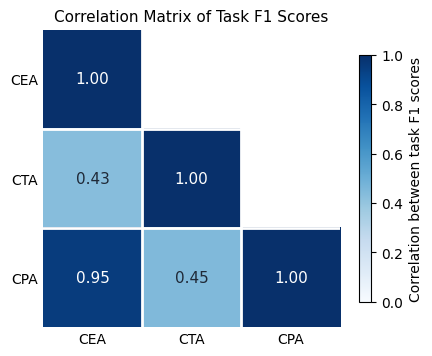

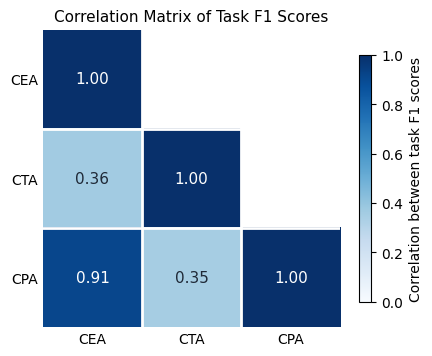

In [36]:
import os

import matplotlib.pyplot as plt
import numpy as np

CORRELATION_ROOT = "Testing_data/Ranking"

run_directories = {}
for directory_path, directory_names, file_names in os.walk(CORRELATION_ROOT):
    if "ranking_other_dataset" in directory_path.replace(os.sep, "/"):
        continue
    if {"cea.csv", "cta.csv", "cpa.csv"} <= set(file_names):
        run_name = os.path.relpath(directory_path, CORRELATION_ROOT).replace(os.sep, "/")
        run_directories[run_name] = directory_path.replace(os.sep, "/")

cea_gold_per_cell = {}
for row in pd.read_csv("Testing_data/cea_gt.csv", names=['tab_id', 'row_id', 'col_id', 'entity'], dtype=str, keep_default_na=False).itertuples():
    cea_gold_per_cell[(row.tab_id, row.row_id, row.col_id)] = row.entity.lower().split()

cta_gold_per_column = {}
for row in pd.read_csv("Testing_data/cta_gt.csv", names=['tab_id', 'col_id', 'type'], dtype=str, keep_default_na=False).itertuples():
    cta_gold_per_column[(row.tab_id, row.col_id)] = row.type

cpa_gold_per_pair = {}
for row in pd.read_csv("Testing_data/cpa_gt.csv", names=['tab_id', 'sub_col_id', 'obj_col_id', 'property'], dtype=str, keep_default_na=False).itertuples():
    cpa_gold_per_pair[(row.tab_id, row.sub_col_id, row.obj_col_id)] = row.property.lower()

def f1_from_counts(correct_total, annotated_total, gold_total):
    precision = correct_total / annotated_total if annotated_total else 0.0
    recall = correct_total / gold_total
    return (2 * precision * recall) / (precision + recall) if precision + recall else 0.0

def cea_f1(submission_file):
    annotated_total = 0
    correct_total = 0
    for row in pd.read_csv(submission_file, names=['tab_id', 'row_id', 'col_id', 'entity'], dtype=str, keep_default_na=False).itertuples():
        cell_key = (row.tab_id, row.row_id, row.col_id)
        if cell_key not in cea_gold_per_cell:
            continue
        annotated_total += 1
        if normalize_entity(row.entity).lower() in cea_gold_per_cell[cell_key]:
            correct_total += 1
    return f1_from_counts(correct_total, annotated_total, len(cea_gold_per_cell))

def cta_f1(submission_file):
    annotated_total = 0
    total_score = 0.0
    for row in pd.read_csv(submission_file, names=['tab_id', 'col_id', 'annotation'], dtype=str, keep_default_na=False).itertuples():
        annotated_total += 1
        column_key = (row.tab_id, row.col_id)
        if column_key not in cta_gold_per_column:
            continue
        total_score += cta_column_score(normalize_entity(row.annotation).lower(), cta_gold_per_column[column_key])
    return f1_from_counts(total_score, annotated_total, len(cta_gold_per_column))

def cpa_f1(submission_file):
    annotated_total = 0
    correct_total = 0
    for row in pd.read_csv(submission_file, names=['tab_id', 'sub_col_id', 'obj_col_id', 'property'], dtype=str, keep_default_na=False).itertuples():
        pair_key = (row.tab_id, row.sub_col_id, row.obj_col_id)
        if pair_key not in cpa_gold_per_pair:
            continue
        annotated_total += 1
        if normalize_property(row.property).lower() == cpa_gold_per_pair[pair_key]:
            correct_total += 1
    return f1_from_counts(correct_total, annotated_total, len(cpa_gold_per_pair))

score_rows = []
for run_name, run_directory in sorted(run_directories.items()):
    score_rows.append({
        "run": run_name,
        "cea": cea_f1(run_directory + "/cea.csv"),
        "cta": cta_f1(run_directory + "/cta.csv"),
        "cpa": cpa_f1(run_directory + "/cpa.csv"),
    })
score_frame = pd.DataFrame(score_rows).set_index("run")
display(score_frame.round(3))

correlation_matrices = {
    "Pearson": score_frame.corr(),
    "Spearman": score_frame.corr(method="spearman")
}

task_labels = [name.upper() for name in score_frame.columns]
upper_triangle_mask = np.triu(np.ones((3, 3), dtype=bool), k=1)
for matrix_name, matrix in correlation_matrices.items():
    figure, axis = plt.subplots(figsize=(4.8, 4))
    heatmap = axis.imshow(np.ma.masked_where(upper_triangle_mask, matrix.values), cmap="Blues", vmin=0, vmax=1)
    axis.set_xticks(range(3), task_labels)
    axis.set_yticks(range(3), task_labels)
    axis.set_xticks([0.5, 1.5], minor=True)
    axis.set_yticks([0.5, 1.5], minor=True)
    axis.grid(which="minor", color="white", linewidth=2)
    axis.tick_params(length=0, which="both")
    for spine in axis.spines.values():
        spine.set_visible(False)
    for row_position in range(3):
        for column_position in range(row_position + 1):
            value = matrix.iloc[row_position, column_position]
            axis.text(column_position, row_position, "%.2f" % value, ha="center", va="center", color="white" if value > 0.6 else "#1f2937", fontsize=11)
    axis.set_title("Correlation Matrix of Task F1 Scores", fontsize=11)
    figure.colorbar(heatmap, ax=axis, shrink=0.8, label="Correlation between task F1 scores")
    plt.show()
